In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

In [54]:
path = "data/AO026_20181122_180943.nwb"
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe().copy()
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    spike_times = []
    for i in np.where(unit_mask)[0]:
        st = nwb.units["spike_times"][i]
        spike_times.append(np.asarray(st))

print("Number of selected units:", len(spike_times))
print("Example spike train length:", len(spike_times[0]))
print("First 10 spikes:", spike_times[0][:10])

Number of selected units: 30
Example spike train length: 2727
First 10 spikes: [4.14076667 4.1556     4.47973333 4.48993333 6.58133333 6.61876667
 6.63066667 6.78743333 6.8086     6.86803333]


In [55]:
Bin_size = 0.01
AP_Bin_Resolution = 1.0 / Bin_size

duration = float(tr["stop_time"].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)

for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("Total spikes in AP:", AP_Bin_Matrx.sum())

Total spikes in AP: 431640.0


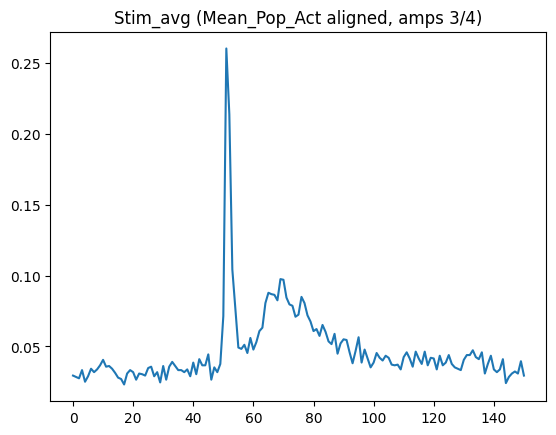

In [56]:
Whisker_Stim_times_H = np.sort(TrialOnsets_All[(StimAmps == 4) | (StimAmps == 3)])

STM_MTRX = np.zeros((len(Whisker_Stim_times_H), 151), dtype=np.float32)

for t, ev in enumerate(Whisker_Stim_times_H):
    this_stim_pt = int(np.round(ev * AP_Bin_Resolution))
    pt1 = this_stim_pt - 50
    pt2 = this_stim_pt + 100
    if pt1 < 0 or pt2 >= Mean_Pop_Act.shape[0]:
        continue
    STM_MTRX[t, :] = Mean_Pop_Act[pt1:pt2+1]

Stim_avg = STM_MTRX.mean(axis=0)

plt.figure()
plt.plot(Stim_avg)
plt.title("Stim_avg (Mean_Pop_Act aligned, amps 3/4)")
plt.show()

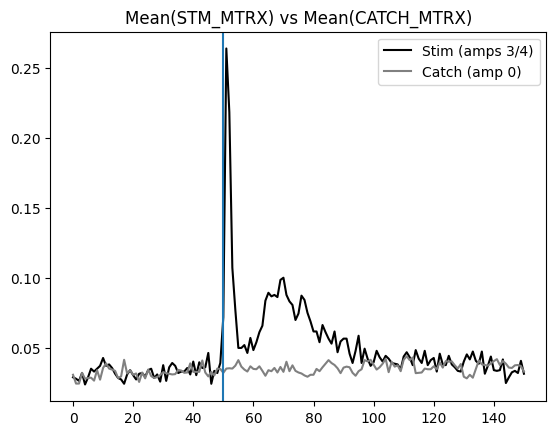

In [57]:
if MissIndices_All is not None:
    stim_mask = ((StimAmps == 4) | (StimAmps == 3)) & (MissIndices_All == 0)
else:
    stim_mask = ((StimAmps == 4) | (StimAmps == 3))

Whisker_Stim_times_H = np.sort(TrialOnsets_All[stim_mask])
Catch_times = TrialOnsets_All[StimAmps == 0]

STM_MTRX = np.zeros((AP_Bin_Matrx.shape[0], 151), dtype=np.float32)
for ev in Whisker_Stim_times_H:
    this_stim_pt = int(np.round(ev * AP_Bin_Resolution))
    pt1 = this_stim_pt - 50
    pt2 = this_stim_pt + 100
    if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
        continue
    STM_MTRX += AP_Bin_Matrx[:, pt1:pt2+1]
STM_MTRX /= max(len(Whisker_Stim_times_H), 1)

CATCH_MTRX = np.zeros((AP_Bin_Matrx.shape[0], 151), dtype=np.float32)
for ev in Catch_times:
    this_stim_pt = int(np.round(ev * AP_Bin_Resolution))
    pt1 = this_stim_pt - 50
    pt2 = this_stim_pt + 100
    if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
        continue
    CATCH_MTRX += AP_Bin_Matrx[:, pt1:pt2+1]
CATCH_MTRX /= max(len(Catch_times), 1)

plt.figure()
plt.plot(STM_MTRX.mean(axis=0), color="black", label="Stim (amps 3/4)")
plt.plot(CATCH_MTRX.mean(axis=0), color="gray", label="Catch (amp 0)")
plt.axvline(50)  # time 0 bin
plt.legend()
plt.title("Mean(STM_MTRX) vs Mean(CATCH_MTRX)")
plt.show()

In [58]:
Pop_Vect_Stim = STM_MTRX[:, 50:55].mean(axis=1)
Pop_Vect_Catch = CATCH_MTRX[:, 50:55].mean(axis=1)

CD_Stim = Pop_Vect_Stim - Pop_Vect_Catch
CD_Stim = CD_Stim / (np.linalg.norm(CD_Stim) + 1e-12)

print("CD_Stim norm:", np.linalg.norm(CD_Stim), "shape:", CD_Stim.shape)

CD_Stim norm: 1.0 shape: (30,)


In [59]:
Projected_Act_CD_Stim = CD_Stim @ AP_Bin_Matrx  # shape (n_bins,)
print(Projected_Act_CD_Stim.shape)

(388288,)


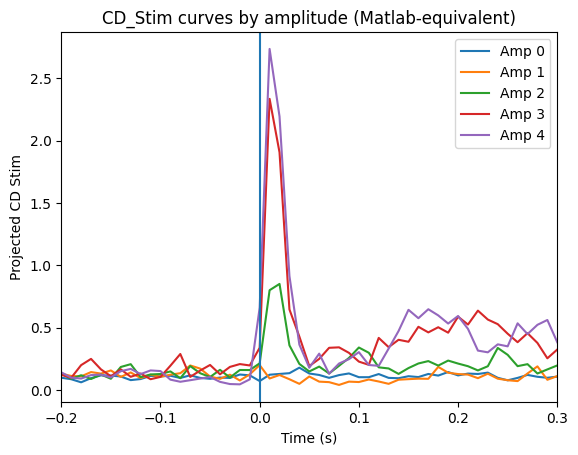

In [60]:
t_bef = 0.2
t_aft = 0.3
pt_bef = int(np.round(t_bef / Bin_size))
pt_aft = int(np.round(t_aft / Bin_size))
win = pt_bef + pt_aft + 1

def align_1d(signal, event_times):
    M = []
    for ev in event_times:
        c = int(np.round(ev / Bin_size))
        pt1 = c - pt_bef
        pt2 = c + pt_aft
        if pt1 < 0 or pt2 >= len(signal):
            continue
        M.append(signal[pt1:pt2+1])
    return np.stack(M, axis=0) if len(M) else np.zeros((0, win), dtype=signal.dtype)

CD_Stim_by_amp = {}
CD_Stim_distrib_by_amp = {}

for Amp in range(0, 5):
    ev_times = TrialOnsets_All[StimAmps == Amp]
    M = align_1d(Projected_Act_CD_Stim, ev_times)
    
    CD_Stim_by_amp[Amp] = M.mean(axis=0) if M.shape[0] else np.zeros(win)
    
    # Matlab: max over bins 21:31 (1-indexed) => Python 20:31
    if M.shape[0]:
        CD_Stim_distrib_by_amp[Amp] = np.max(M[:, 20:31], axis=1)
    else:
        CD_Stim_distrib_by_amp[Amp] = np.array([], dtype=float)

t_vect = np.linspace(-t_bef, t_aft, win)

plt.figure()
for Amp in range(0, 5):
    plt.plot(t_vect, CD_Stim_by_amp[Amp], label=f"Amp {Amp}")
plt.axvline(0)
plt.xlim([-t_bef, t_aft])
plt.xlabel("Time (s)")
plt.ylabel("Projected CD Stim")
plt.legend()
plt.title("CD_Stim curves by amplitude (Matlab-equivalent)")
plt.show()

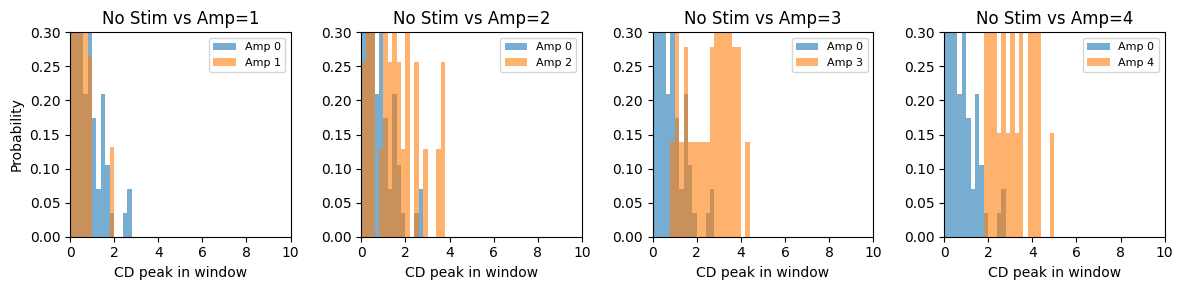

In [61]:
bin_width = 0.2
pairs = [(0,1), (0,2), (0,3), (0,4)]

plt.figure(figsize=(12, 3))
for i, (a0, a1) in enumerate(pairs, 1):
    plt.subplot(1,4,i)
    plt.hist(CD_Stim_distrib_by_amp[a0], bins=np.arange(0, 10+bin_width, bin_width), density=True, alpha=0.6, label=f"Amp {a0}")
    plt.hist(CD_Stim_distrib_by_amp[a1], bins=np.arange(0, 10+bin_width, bin_width), density=True, alpha=0.6, label=f"Amp {a1}")
    plt.xlim([0,10])
    plt.ylim([0,0.3])
    plt.title(f"No Stim vs Amp={a1}")
    if i == 1:
        plt.ylabel("Probability")
    plt.xlabel("CD peak in window")
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

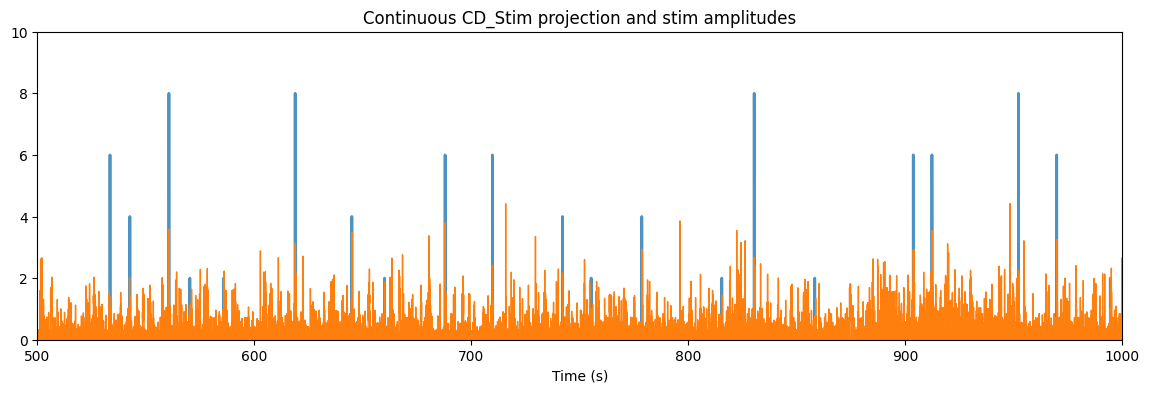

In [62]:
cont_t_vect = np.arange(len(Projected_Act_CD_Stim)) * Bin_size

Stim_Vect_Amp = np.zeros(len(Projected_Act_CD_Stim), dtype=float)

# Matlab uses all trial onsets and amps; only non-zero amps mark stim vector
for ev, amp in zip(TrialOnsets_All, StimAmps):
    if amp != 0:
        pt_stim = int(np.round(ev / Bin_size))
        if 0 <= pt_stim < len(Stim_Vect_Amp):
            Stim_Vect_Amp[pt_stim] = amp

plt.figure(figsize=(14,4))
plt.plot(cont_t_vect, Stim_Vect_Amp * 2, linewidth=2, alpha=0.8)  # like Matlab *2 for visibility
plt.plot(cont_t_vect, Projected_Act_CD_Stim, linewidth=1)
plt.xlim([500, 1000])
plt.ylim([0, 10])
plt.xlabel("Time (s)")
plt.title("Continuous CD_Stim projection and stim amplitudes")
plt.show()

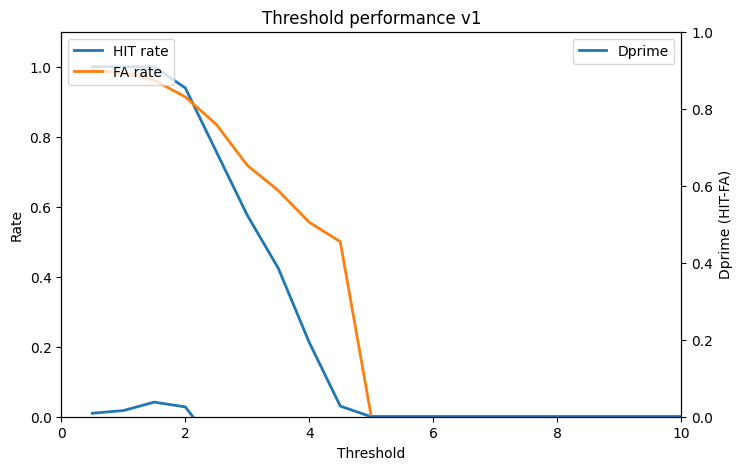

In [63]:
Thrs_Max = 10
Thrs_min = 0.5
Thrs_Step = 0.5
Thrs_vals = np.arange(Thrs_Max, Thrs_min - 1e-9, -Thrs_Step)

Time_Wind = 0.1

Whisker_Stim_times_H = np.sort(TrialOnsets_All[StimAmps == 4])
Whisker_Stim_times_C = np.sort(TrialOnsets_All[(StimAmps >= 1) & (StimAmps <= 4)])

HIT_rate = []
FA_rate = []

for Thrs_i in Thrs_vals:
    # HIT detection on amp 4 trials
    detected = []
    for ev in Whisker_Stim_times_H:
        pt1 = int(np.round(ev / Bin_size))
        pt2 = int(np.round((ev + Time_Wind) / Bin_size))
        pt2 = min(pt2, len(Projected_Act_CD_Stim)-1)
        detected.append(np.max(Projected_Act_CD_Stim[pt1:pt2+1]) > Thrs_i)
    hit = np.mean(detected) if len(detected) else np.nan
    HIT_rate.append([Thrs_i, hit])

    # Peaks above threshold
    peaks, props = find_peaks(Projected_Act_CD_Stim, height=Thrs_i)
    peak_times = peaks * Bin_size

    false = []
    for pt in peak_times:
        # Matlab: Time_Diff = Whisker_Stim_times_C - Peak_time
        # false if NO stim occurred in (Peak_time - Time_Wind, Peak_time]
        dt = Whisker_Stim_times_C - pt
        ok = np.any((dt < 0) & (dt > -Time_Wind))
        false.append(not ok)
    fa = np.mean(false) if len(false) else 0.0
    FA_rate.append([Thrs_i, fa])

HIT_rate = np.array(HIT_rate, dtype=float)
FA_rate = np.array(FA_rate, dtype=float)

# Matlab clamps 0/1 for dprime, then does HIT-FA (not norminv)
hit_dp = HIT_rate[:,1].copy()
fa_dp = FA_rate[:,1].copy()
hit_dp[hit_dp == 0] = 0.001
hit_dp[hit_dp == 1] = 0.999
fa_dp[fa_dp == 0] = 0.001
fa_dp[fa_dp == 1] = 0.999
Dprime = hit_dp - fa_dp

plt.figure(figsize=(8,5))
ax = plt.gca()
ax.plot(HIT_rate[:,0], HIT_rate[:,1], linewidth=2, label="HIT rate")
ax.plot(FA_rate[:,0], FA_rate[:,1], linewidth=2, label="FA rate")
ax.set_xlim([0,10])
ax.set_ylim([0,1.1])
ax.set_xlabel("Threshold")
ax.set_ylabel("Rate")
ax2 = ax.twinx()
ax2.plot(HIT_rate[:,0], Dprime, linewidth=2, label="Dprime")
ax2.set_ylim([0,1])
ax2.set_ylabel("Dprime (HIT-FA)")
ax.set_title("Threshold performance v1")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

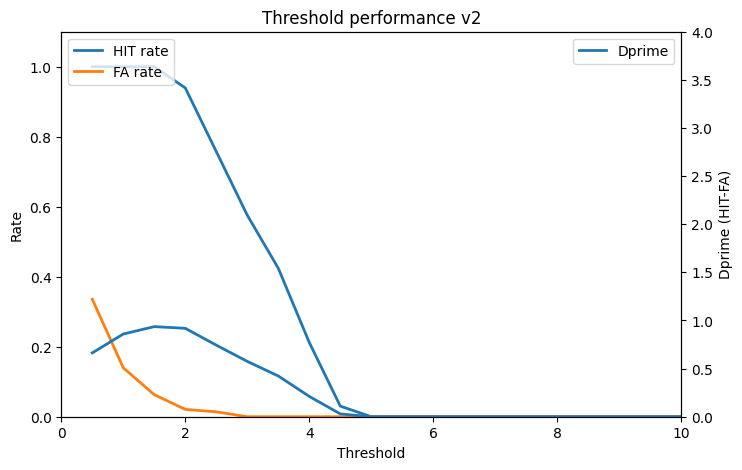

In [64]:
Thrs_Max = 10
Thrs_min = 0.5
Thrs_Step = 0.5
Thrs_vals = np.arange(Thrs_Max, Thrs_min - 1e-9, -Thrs_Step)

Time_Wind = 0.1

Whisker_Stim_times_H = np.sort(TrialOnsets_All[StimAmps == 4])
Catch_times = np.sort(TrialOnsets_All[StimAmps == 0])

HIT_rate2 = []
FA_rate2 = []

for Thrs_i in Thrs_vals:
    # HIT detection on amp 4 trials
    detected = []
    for ev in Whisker_Stim_times_H:
        pt1 = int(np.round(ev / Bin_size))
        pt2 = int(np.round((ev + Time_Wind) / Bin_size))
        pt2 = min(pt2, len(Projected_Act_CD_Stim)-1)
        detected.append(np.max(Projected_Act_CD_Stim[pt1:pt2+1]) > Thrs_i)
    hit = np.mean(detected) if len(detected) else np.nan
    HIT_rate2.append([Thrs_i, hit])

    # False alarms measured on catch windows
    false = []
    for ev in Catch_times:
        pt1 = int(np.round(ev / Bin_size))
        pt2 = int(np.round((ev + Time_Wind) / Bin_size))
        pt2 = min(pt2, len(Projected_Act_CD_Stim)-1)
        false.append(np.max(Projected_Act_CD_Stim[pt1:pt2+1]) > Thrs_i)
    fa = np.mean(false) if len(false) else np.nan
    FA_rate2.append([Thrs_i, fa])

HIT_rate2 = np.array(HIT_rate2, dtype=float)
FA_rate2 = np.array(FA_rate2, dtype=float)

hit_dp = HIT_rate2[:,1].copy()
fa_dp = FA_rate2[:,1].copy()
hit_dp[hit_dp == 0] = 0.001
hit_dp[hit_dp == 1] = 0.999
fa_dp[fa_dp == 0] = 0.001
fa_dp[fa_dp == 1] = 0.999
Dprime2 = hit_dp - fa_dp

plt.figure(figsize=(8,5))
ax = plt.gca()
ax.plot(HIT_rate2[:,0], HIT_rate2[:,1], linewidth=2, label="HIT rate")
ax.plot(FA_rate2[:,0], FA_rate2[:,1], linewidth=2, label="FA rate")
ax.set_xlim([0,10])
ax.set_ylim([0,1.1])
ax.set_xlabel("Threshold")
ax.set_ylabel("Rate")
ax2 = ax.twinx()
ax2.plot(HIT_rate2[:,0], Dprime2, linewidth=2, label="Dprime")
ax2.set_ylim([0,4])
ax2.set_ylabel("Dprime (HIT-FA)")
ax.set_title("Threshold performance v2")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()